**Churn Prediction**

*imports for churn prediction*

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


**building features**

In [19]:
churn_df = pd.read_csv('olist_augmented_data/customer_rfm_augmented.csv')
customers = pd.read_csv('olist_augmented_data/order_items_augmented.csv')
orders = pd.read_csv('olist_augmented_data/orders_augmented.csv')
payments = pd.read_csv('olist_augmented_data/order_payments_augmented.csv')
churn_df['avg_order_value'] = churn_df['monetary'] / churn_df['frequency']


In [20]:
customer_dates = orders.groupby('customer_id')['order_purchase_timestamp'].agg(['min', 'max']).reset_index()
customer_dates.columns = ['customer_id', 'first_purchase', 'last_purchase']
customer_dates['first_purchase'] = pd.to_datetime(customer_dates['first_purchase'])
customer_dates['last_purchase'] = pd.to_datetime(customer_dates['last_purchase'])

customer_dates['customer_lifetime_days'] = (customer_dates['last_purchase'] - customer_dates['first_purchase']).dt.days
churn_df = churn_df.merge(customer_dates[['customer_id', 'customer_lifetime_days']], on='customer_id', how='left')

In [21]:
churn_df['purchase_frequency_rate'] = churn_df['frequency'] / (churn_df['customer_lifetime_days'] + 1) 
churn_threshold_days = 180
churn_df['churned'] = (churn_df['recency'] > churn_threshold_days).astype(int) 

churn_df = churn_df.fillna(0)

print(f"Total customers : {len(churn_df)}")
print(f"Churned         : {churn_df['churned'].sum()} ({churn_df['churned'].mean()*100:.1f}%)")
print(f"Active          : {(1 - churn_df['churned']).sum()} ({(1 - churn_df['churned']).mean()*100:.1f}%)")
print("\nSample:")
print(churn_df[['customer_id', 'recency', 'frequency', 'monetary', 'churned']].head())

Total customers : 99433
Churned         : 59138 (59.5%)
Active          : 40295 (40.5%)

Sample:
                        customer_id  recency  frequency  monetary  churned
0  00012a2ce6f8dcda20d059ce98491703      338          1    114.74        1
1  000161a058600d5901f007fab4c27140      276          3   1086.74        1
2  0001fd6190edaaf884bcaf3d49edf079      597          1    195.42        1
3  0002414f95344307404f0ace7a26f1d5      428          1    179.35        1
4  000379cdec625522490c315e70c7a9fb      199          1    107.01        1


**Train/Test Split & Scaling**

In [22]:
feature_columns = ['recency', 'frequency', 'monetary', 'avg_order_value',
                   'customer_lifetime_days', 'purchase_frequency_rate']

X = churn_df[feature_columns]
y = churn_df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")
print("Features scaled")

Train : 79546 samples
Test  : 19887 samples
Features scaled


**Train Models**

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=10,
    min_samples_split=20, class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf       = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_rf      = roc_auc_score(y_test, y_pred_proba_rf)

lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr       = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_lr      = roc_auc_score(y_test, y_pred_proba_lr)

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=['Active', 'Churned']))
print(f"ROC-AUC: {roc_auc_rf:.4f}")

print("\nLOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=['Active', 'Churned']))
print(f"ROC-AUC: {roc_auc_lr:.4f}")

best_model = 'Random Forest' if roc_auc_rf >= roc_auc_lr else 'Logistic Regression'
print(f"\nBest Model: {best_model}")

RANDOM FOREST
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      8059
     Churned       1.00      1.00      1.00     11828

    accuracy                           1.00     19887
   macro avg       1.00      1.00      1.00     19887
weighted avg       1.00      1.00      1.00     19887

ROC-AUC: 1.0000

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Active       0.99      1.00      1.00      8059
     Churned       1.00      0.99      1.00     11828

    accuracy                           1.00     19887
   macro avg       1.00      1.00      1.00     19887
weighted avg       1.00      1.00      1.00     19887

ROC-AUC: 1.0000

Best Model: Random Forest


*Visualizations*

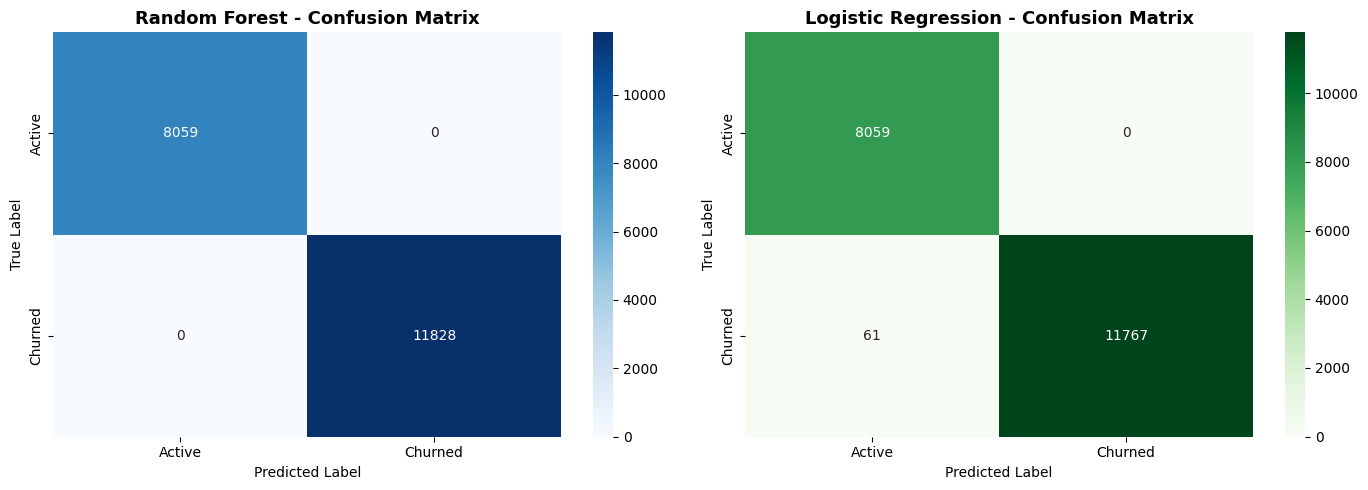

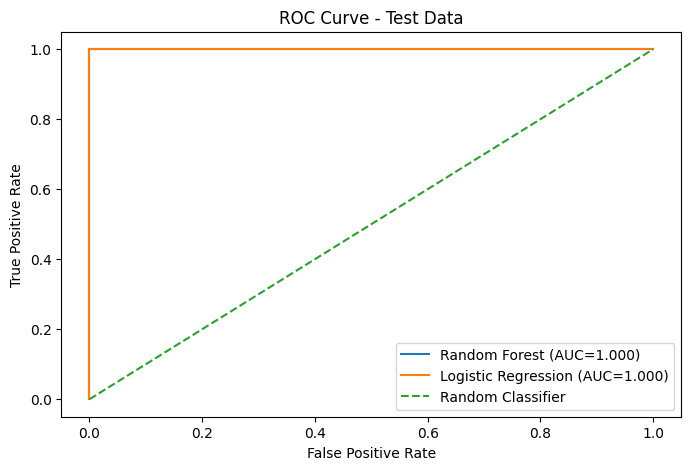

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_rf, y_pred_lr],
    ['Random Forest', 'Logistic Regression'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Active', 'Churned'],
                yticklabels=['Active', 'Churned'])
    ax.set_title(f'{title} - Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

plt.figure(figsize=(8,5))

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_lr:.3f})')

plt.plot([0,1], [0,1], linestyle='--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.show()

 **Score All Customers & Risk Segmentation**

In [27]:
X_all_scaled = scaler.transform(churn_df[feature_columns])

churn_df['churn_probability_rf'] = rf_model.predict_proba(X_all_scaled)[:, 1]
churn_df['churn_probability_lr'] = lr_model.predict_proba(X_all_scaled)[:, 1]
churn_df['churn_prediction']     = rf_model.predict(X_all_scaled)

def categorize_risk(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn_df['risk_category'] = churn_df['churn_probability_rf'].apply(categorize_risk)

high_risk = churn_df[churn_df['risk_category'] == 'High Risk'].sort_values(
    'churn_probability_rf', ascending=False
)

print("Risk Distribution:")
print(churn_df['risk_category'].value_counts())

print(f"\nTop 10 High-Risk Customers:")
print(high_risk[['customer_id', 'recency', 'frequency', 'monetary', 'churn_probability_rf']].head(10).to_string(index=False))



Risk Distribution:
risk_category
High Risk    59138
Low Risk     40295
Name: count, dtype: int64

Top 10 High-Risk Customers:
                     customer_id  recency  frequency  monetary  churn_probability_rf
000fd45d6fedae68fc6676036610f879      186          2    243.90                   1.0
fff25ab9d3c9ba6ad8119576f285a3d9      532          1    220.71                   1.0
fff4fdd0de70a51d4e0f57a4c1c6bfae      192          1     21.04                   1.0
001f35d9f262c558fd065346fbf5801d      265          3   1461.29                   1.0
60a5aba7b553b44da85505197830d17f      433          1    288.19                   1.0
60b88693a88b8cc33f9e3a0683594e89      286          1    278.22                   1.0
6093facc8a1c13bd8499e221125e9d59      492          1    325.92                   1.0
e499450a060a376c46c82653e112e81d      255          1    220.88                   1.0
0051337a96842850e1ec728dd158f4b3      626          1    237.99                   1.0
005196c65bab2861e397cc85

In [28]:
print(f"""
Total Customers  : {len(churn_df)}
Churned          : {churn_df['churned'].sum()} ({churn_df['churned'].mean()*100:.1f}%)
Active           : {(1-churn_df['churned']).sum()} ({(1-churn_df['churned']).mean()*100:.1f}%)

RF  ROC-AUC      : {roc_auc_rf:.4f}
LR  ROC-AUC      : {roc_auc_lr:.4f}
Best Model       : {best_model}

""")


Total Customers  : 99433
Churned          : 59138 (59.5%)
Active           : 40295 (40.5%)

RF  ROC-AUC      : 1.0000
LR  ROC-AUC      : 1.0000
Best Model       : Random Forest


